### Master of Applied Artificial Intelligence

**Course: TC5035 - Cuadro Inteligente**

<img src="../assets/logo.png" alt="Image Alt Text" width="500"/>


**Exploratory Data Analysis**

Tutor: Dr. Horario Martinez Alfaro


Team members:
* Ignacio Jose Aguilar Garcia - A00819762
* Alejandro Calderon Aguilar - A01795353
* Ricardo Mar Cupido - A01795394


¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia? 
¿Cuáles son las estadísticas resumidas del conjunto de datos?
¿Hay valores atípicos en el conjunto de datos?
¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?
¿Hay correlación entre las variables dependientes e independientes?
¿Cómo se distribuyen los datos en función de diferentes categorías? (análisis bivariado)


# 1. Import dependencies

In [135]:
import sys
sys.path.append('../')

In [164]:
import importlib, scripts.plotting_helpers as ph
importlib.reload(ph)
from scripts.helpers import download_data
from scripts.plotting_helpers import plot_histogram, plot_target, plot_bar, plot_bivariade_bar, explain_targetWith_cat, plot_correlation, plotBoxplots, correlation_barplot
import pandas as pd
import numpy as np

# 2. EDA



## 2.1 Data Description


* **Location and demographics**

  * **state_name** *(str)*: Customer’s department/state (e.g., GUATEMALA, JALAPA).
  * **state_city_equals** *(binary 0/1)*: Department and city match (address quality).
  * **client_gender** *(str: M/F/na)*: Declared gender.
  * **client_age** *(num)*: Age in years.


* **Previous telemarketing history/classification**

  * **previous_classification** *(str)*: Outcome of the prior outreach (NEW CLIENT, NOT INTERESTED, NOT EFFECTIVE, etc.).
  * **previous_calls** *(int)*: Number of previous calls.
  * **previous_not_effective_count** *(int)*: Prior “not effective” calls.
  * **previous_not_interested_count** *(int)*: Times the customer stated not interested.

* **Identification and seniority in the network**

  * **client_has_nit** *(binary)*: Has tax ID (1) or not (0).
  * **network_age_years** *(num)*: Tenure on the network (years).
  * **start_using_months** *(int)*: Months since first line usage.
  * **imei_first_use_months** *(int)*: Months since the IMEI first appeared on the network.
  * **imei_distinct_users** *(int)*: Number of distinct users for that IMEI.

* **Product portfolio (RGUs) and plan**

  * **rgus_prepaid / rgus_postpaid / rgus_home** *(int)*: Active products by type.
  * **plan_postpaid** *(binary)*: Has an active postpaid plan (1/0).
  * **class** *(int)*: Internal device/customer segment/score (e.g., 3/4/5).
  * **socioeconomic_level** *(str: A–E, C-, C+, etc.)*: Estimated socioeconomic level.

* **Banking and financial affinity**

  * **banking** *(binary)*: Banked per internal/external sources.
  * **sn_banking** *(binary)*: Social/alternative banking signal.
  * **digital_tokenized_card** *(binary)*: Has a tokenized card in Tigo’s digital ecosystem.

* **Billing, spending and network usage**

  * **arpu_90_days** *(num, currency)*: Average ARPU over the last 90 days.
  * **navegation_gb** *(num, GB)*: Total mobile data consumed.
  * **minutes_out / minutes_in** *(num, min)*: Outgoing/incoming minutes.
  * **percent_of_weeks_with_data_purchase** *(0–1)*: Share of weeks with a data purchase.
  * **purchase_average** *(num)*: Average top-up/purchase ticket.
  * **validity_average** *(num, days)*: Average validity of packages.
  * **average_performance** *(~0–1.5)*: Internal line activity index.
  * **with_international_calls** *(binary)*: Makes international calls.
  * **arpu_gte_100** *(binary)*: ARPU ≥ 100.
  * **navigation_gte_5gb** *(binary)*: Data usage ≥ 5 GB.

* **Technology and device**

  * **network_technology_code** *(str)*: Access technology (3G/4G/5G).
  * **operating_system** *(str)*: Device OS (ANDROID/iOS…).
  * **type_name** *(str)*: Device type (SMARTPHONE, FEATURE PHONE, etc.).
  * **brand_name / model_name** *(str)*: Device brand and model.

* **Social graph / client agenda**

  * **contacts** *(int)*: Detected contacts.
  * **tigo_contacts** *(int)*: Contacts within Tigo’s network.
  * **high_frequency_contacts** *(decimal 0–1)*: Share/score of high-frequency contacts.

* **Tigo Digital Behavior**

  * **digital_months** *(int)*: Months using Tigo digital channels.
  * **digital_index_mean** *(0–1)*: Average digital adoption score.
  * **connected_days / charged_days / apps_days / zero_rate_days** *(int)*: Days with connection, with charging, with app usage, and with zero-rating.

* **Usage by application (engagement)**

  * **facebook_days / facebook_gb** *(int / GB)*: Days and GB on Facebook.
  * **tiktok_days / tiktok_gb** *(int / GB)*: Days and GB on TikTok.
  * **instagram_days / instagram_gb** *(int / GB)*: Days and GB on Instagram.
  * **whatsapp_days / whatsapp_gb** *(int / GB)*: Days and GB on WhatsApp.
  * **youtube_days / youtube_gb** *(int / GB)*: Days and GB on YouTube.
  * **music_days / music_gb** *(int / GB)*: Days and GB on music apps.

* **Derived signals and consistency**

  * **state_city_equals** *(binary)*: (as above) validates address consistency.
  * **C+, C-, D, E** *(in `socioeconomic_level`)*: Ordinal coding for targeting.

* **Target variable**

  * **sale** *(str: YES/NO)*: Sales/contact outcome (model target).

## 2.2 Download dataset

**Important: the following csv file is completly confidencial, it's not allowed to scam it**

In [ ]:
output_path: str = "../data/sale.csv"
download_data(url='https://drive.google.com/uc?export=download&id=1rmHf8nMsml059APC6ftFytKjVlUnbOUp', output_path=output_path)

📥 Descargando archivo desde:
https://drive.google.com/uc?export=download&id=1rmHf8nMsml059APC6ftFytKjVlUnbOUp


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1rmHf8nMsml059APC6ftFytKjVlUnbOUp
From (redirected): https://drive.google.com/uc?export=download&id=1rmHf8nMsml059APC6ftFytKjVlUnbOUp&confirm=t&uuid=2d6091be-1be1-4016-a1bc-7b43555c3785
To: /Users/alejandrocalderon/Documents/MIA/integrador/Proyecto-Integrador/notebooks/data/sale.csv
100%|██████████| 299M/299M [03:03<00:00, 1.63MB/s]  

✅ Archivo guardado en: data/sale.csv


## 2.3 Read csv file into a pandas dataframe

In [98]:
df = pd.read_csv(output_path)

## 2.4 Dataframe shape

how many rows and columns the dataframe has ?

In [7]:
df.shape

(610083, 60)

## 2.5 Sales dataset 

Sales dataset view of dataframe

In [99]:
df.head()

,state_name,previous_classification,previous_calls,previous_not_effective_count,previous_not_interested_count,client_gender,client_age,client_has_nit,network_age_years,rgus_prepaid,...,tiktok_gb,instagram_days,instagram_gb,whatsapp_days,whatsapp_gb,youtube_days,youtube_gb,music_days,music_gb,sale
0,JALAPA,NEW CLIENT,0,0,0,M,69.0,1,3.16,3,...,30.321,0,0.000,84,0.693,85,2.745,0,0.000,NO
1,GUATEMALA,NEW CLIENT,0,0,0,F,28.0,1,3.90,2,...,42.442,89,0.425,89,20.237,89,3.614,89,5.946,NO
2,ALTA VERAPAZ,NOT INTERESTED,2,1,1,M,44.0,1,12.88,4,...,7.749,0,0.000,89,21.538,85,1.607,42,0.298,NO
3,CHIMALTENANGO,NOT INTERESTED,3,1,2,M,56.0,1,1.94,6,...,2.739,82,0.125,82,2.072,82,2.454,0,0.000,NO
4,HUEHUETENANGO,NOT INTERESTED,6,4,2,F,45.0,1,13.37,2,...,7.694,64,0.037,87,1.040,76,1.065,23,0.142,NO


In [100]:
df.tail()

,state_name,previous_classification,previous_calls,previous_not_effective_count,previous_not_interested_count,client_gender,client_age,client_has_nit,network_age_years,rgus_prepaid,...,tiktok_gb,instagram_days,instagram_gb,whatsapp_days,whatsapp_gb,youtube_days,youtube_gb,music_days,music_gb,sale
610078,GUATEMALA,NOT INTERESTED,2,1,1,M,35.0,0,0.95,4,...,81.054,0,0.000,88,1.608,88,34.004,0,0.000,NO
610079,QUICHE,NOT EFFECTIVE,1,1,0,NaN,NaN,0,12.99,7,...,18.979,29,0.011,82,5.454,79,13.612,0,0.000,NO
610080,SAN MARCOS,NOT INTERESTED,3,1,2,M,49.0,0,16.86,2,...,15.637,42,0.021,88,1.055,80,0.180,0,0.000,NO
610081,JUTIAPA,NOT EFFECTIVE,2,2,0,F,31.0,0,2.76,4,...,13.597,6,0.005,71,5.436,69,2.022,0,0.000,NO
610082,CHIQUIMULA,NOT EFFECTIVE,1,1,0,M,61.0,0,0.95,6,...,11.724,82,1.562,88,17.860,69,1.036,49,0.451,NO


**sale would it be the variable target, so sale is parse from string to integer32**


* SI = 1
* NO = 0

In [101]:
df['sale'] = (df['sale']=='SI').astype('int32')

## 2.6 Global information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610083 entries, 0 to 610082
Data columns (total 60 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   state_name                           610068 non-null  object 
 1   previous_classification              610083 non-null  object 
 2   previous_calls                       610083 non-null  int64  
 3   previous_not_effective_count         610083 non-null  int64  
 4   previous_not_interested_count        610083 non-null  int64  
 5   client_gender                        458428 non-null  object 
 6   client_age                           458559 non-null  float64
 7   client_has_nit                       610083 non-null  int64  
 8   network_age_years                    610081 non-null  float64
 9   rgus_prepaid                         610083 non-null  int64  
 10  rgus_postpaid                        610083 non-null  int64  
 11  rgus_home    

## 2.7 Numerical variables

In [150]:
numerical_variables = df.select_dtypes(include="number").columns.tolist()
print(f'numerical variables: {len(numerical_variables)}')

numerical variables: 51


The following table describes:

* Measures of central tendency
    * mean
    * median
    

* Measures of dispersion
    * Range
    * Variance
    * Standar deviation


* Measures of position
    * quantiles
    * min
    * max

In [151]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
previous_calls,610083.0,1.406976,1.655471,0.0,0.000,1.000,2.000,28.000
previous_not_effective_count,610083.0,0.950838,1.384682,0.0,0.000,0.000,1.000,28.000
previous_not_interested_count,610083.0,0.456138,0.762280,0.0,0.000,0.000,1.000,17.000
client_age,458559.0,41.237679,12.294965,7.0,32.000,40.000,49.000,2022.000
client_has_nit,610083.0,0.487743,0.499850,0.0,0.000,0.000,1.000,1.000
network_age_years,610081.0,3.756704,3.816662,0.0,1.090,2.530,4.950,25.370
rgus_prepaid,610083.0,10.773570,166.266269,0.0,1.000,2.000,4.000,16060.000
rgus_postpaid,610083.0,2.756890,329.779165,0.0,0.000,0.000,0.000,41590.000
rgus_home,610083.0,0.122000,0.557192,0.0,0.000,0.000,0.000,20.000
banking,610083.0,0.705943,0.455618,0.0,0.000,1.000,1.000,1.000


### 2.7.1 Target variable

Is there an imbalance in the classes of the target variable? 

The dataset is imbalanced: only 3.75 % of the records correspond to sales (positive class), while 96.25 % are non-sales (negative class).

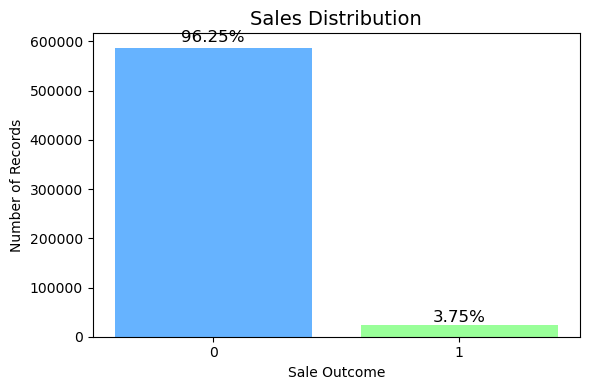

In [152]:
sales_counts = df['sale'].value_counts()
sales_perc = df['sale'].value_counts(normalize=True) * 100

plot_target(sales_counts=sales_counts, sales_perc=sales_perc)

### 2.7.2 Numerical variables distribution

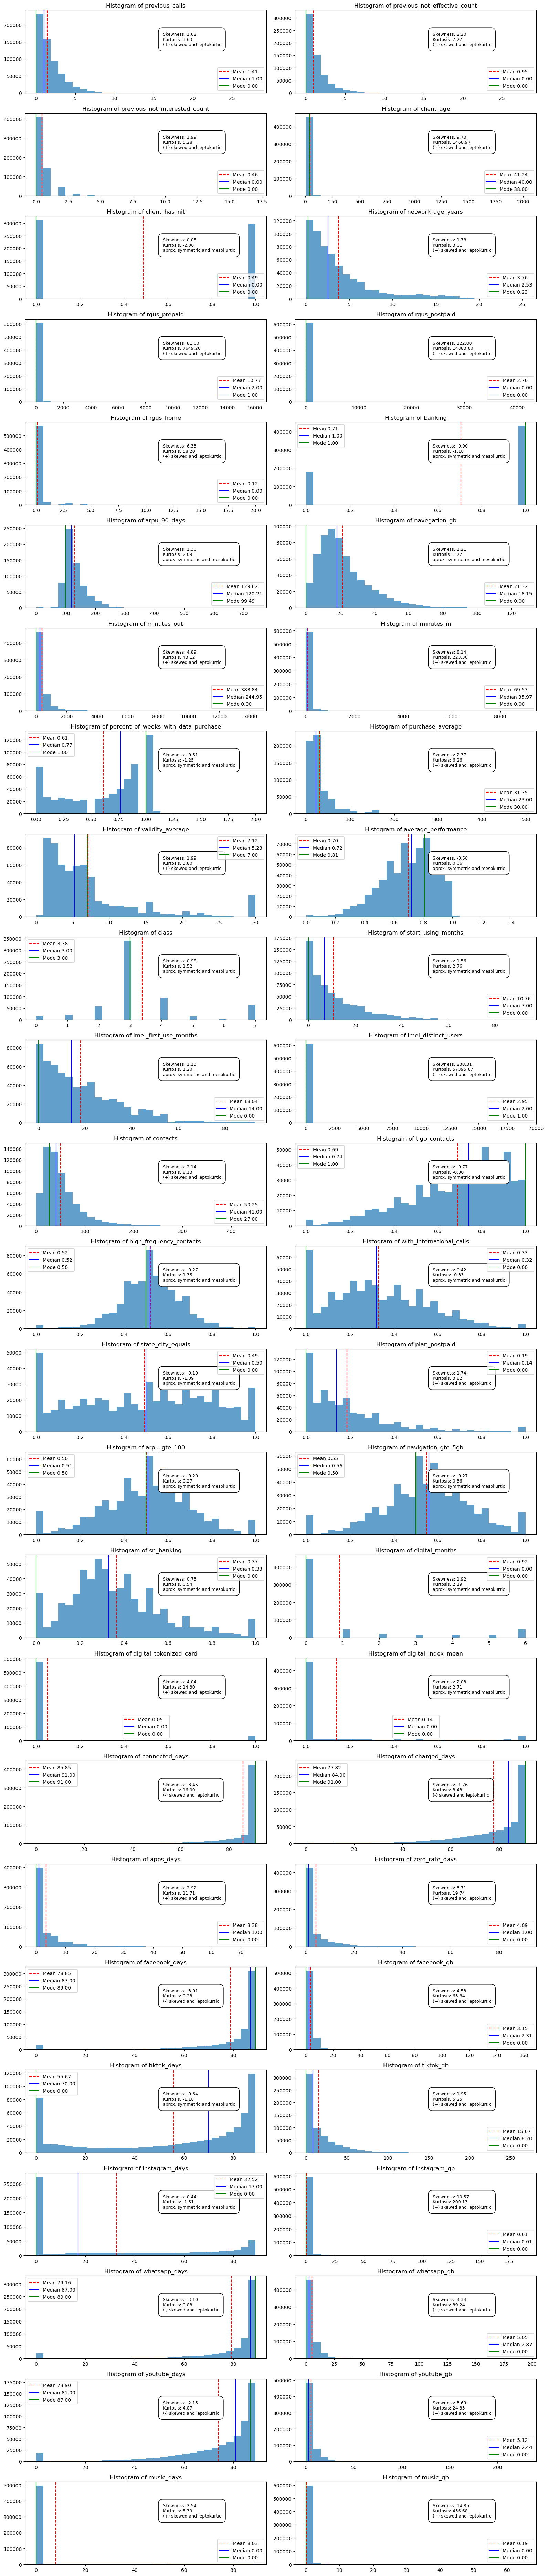

In [94]:
plot_histogram(df, numerical_variables)

### 2.7.3 Correlation

#### Global correlation

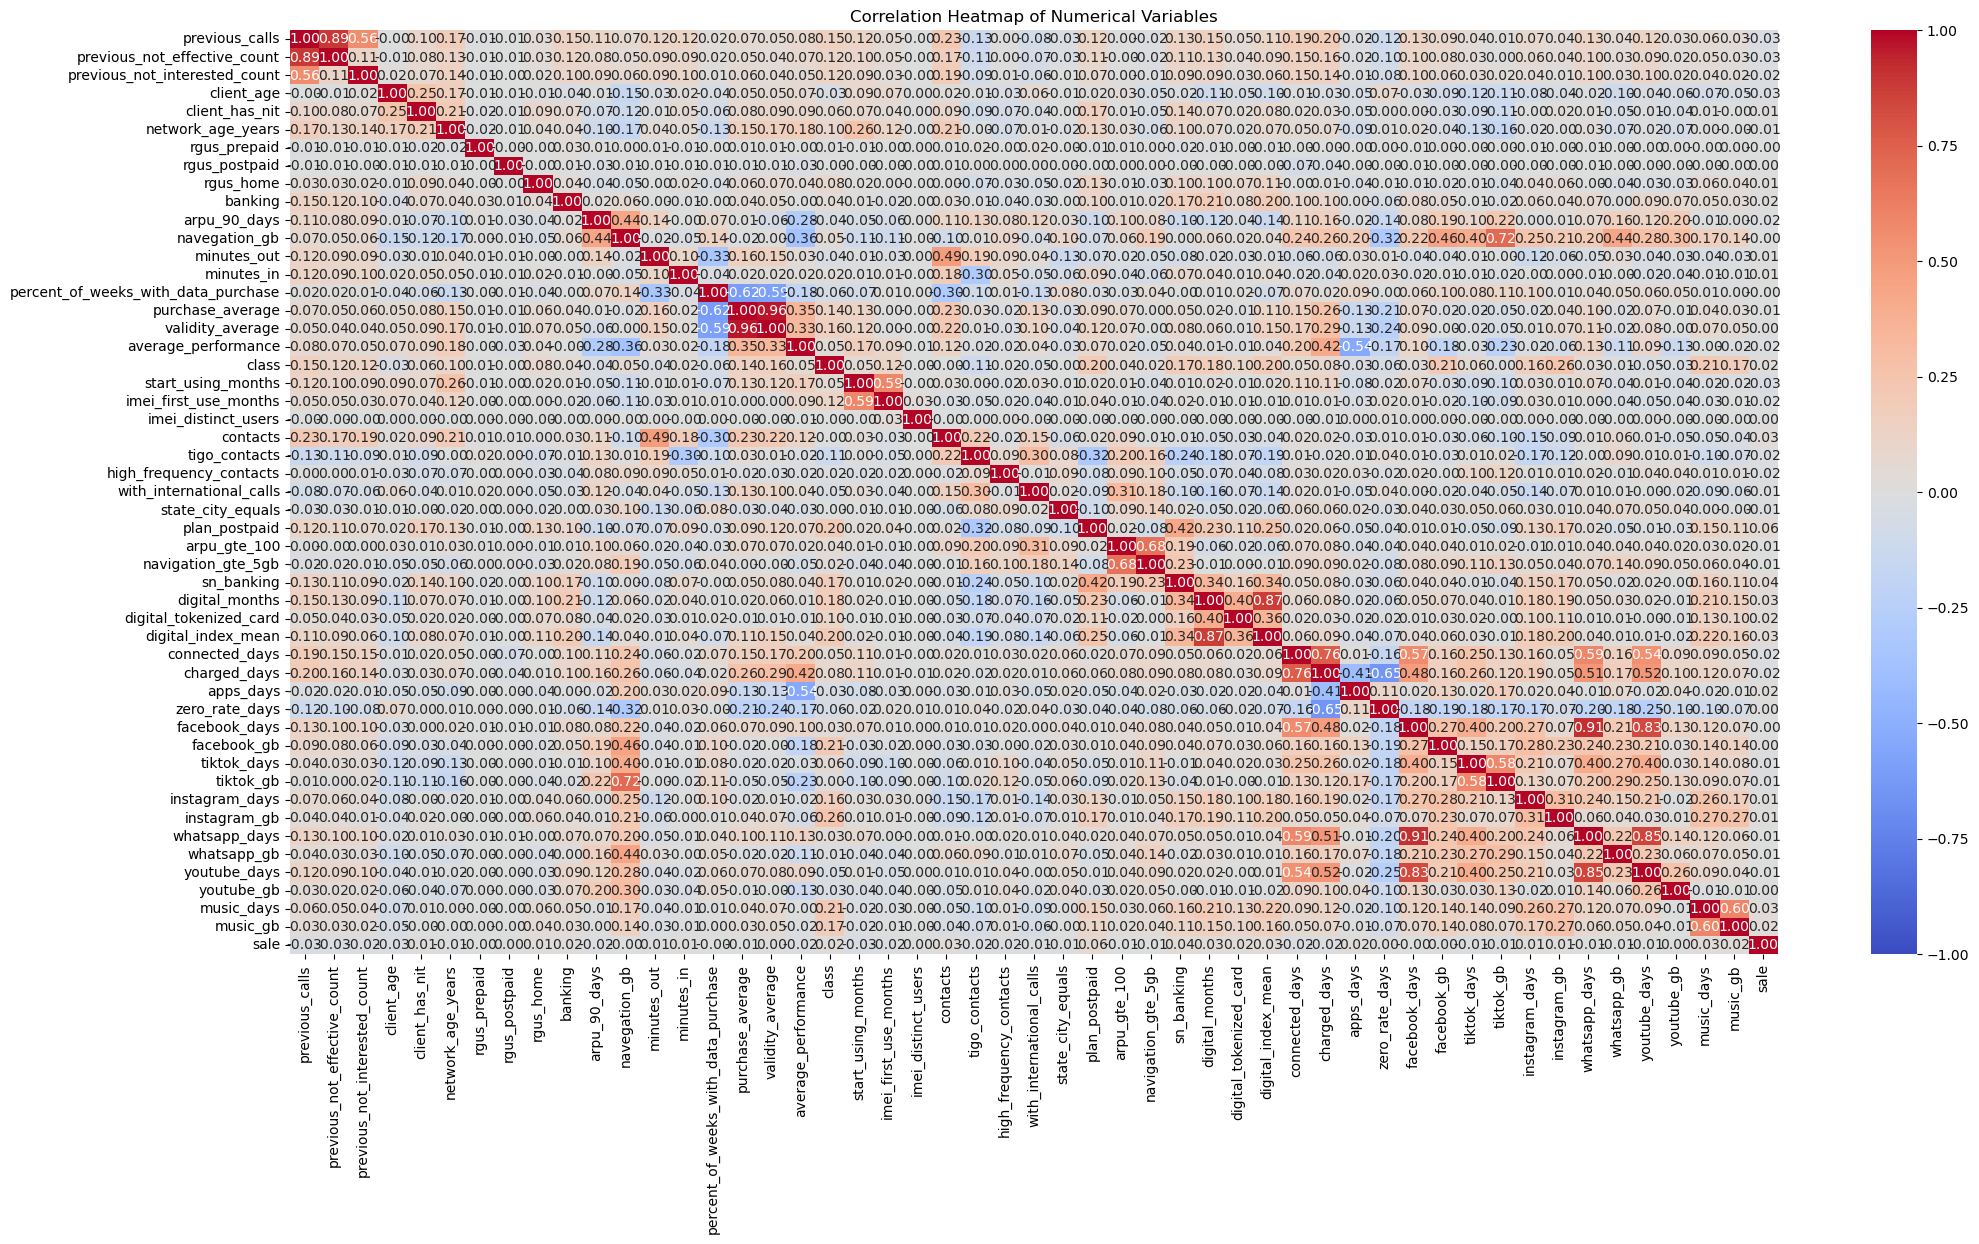

In [158]:
corr = df.corr(numeric_only=True)
plot_correlation(corr=corr, title="Correlation Heatmap of Numerical Variables")

#### Find highly correlated variables

In [156]:
corr_matrix = df.corr(numeric_only=True).abs()

# Upper triangle mask
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.5
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
for var in to_drop:
    print("Highly correlated variables:", var)

Highly correlated variables: previous_not_effective_count
Highly correlated variables: previous_not_interested_count
Highly correlated variables: purchase_average
Highly correlated variables: validity_average
Highly correlated variables: imei_first_use_months
Highly correlated variables: navigation_gte_5gb
Highly correlated variables: digital_index_mean
Highly correlated variables: charged_days
Highly correlated variables: apps_days
Highly correlated variables: zero_rate_days
Highly correlated variables: facebook_days
Highly correlated variables: tiktok_gb
Highly correlated variables: whatsapp_days
Highly correlated variables: youtube_days
Highly correlated variables: music_gb


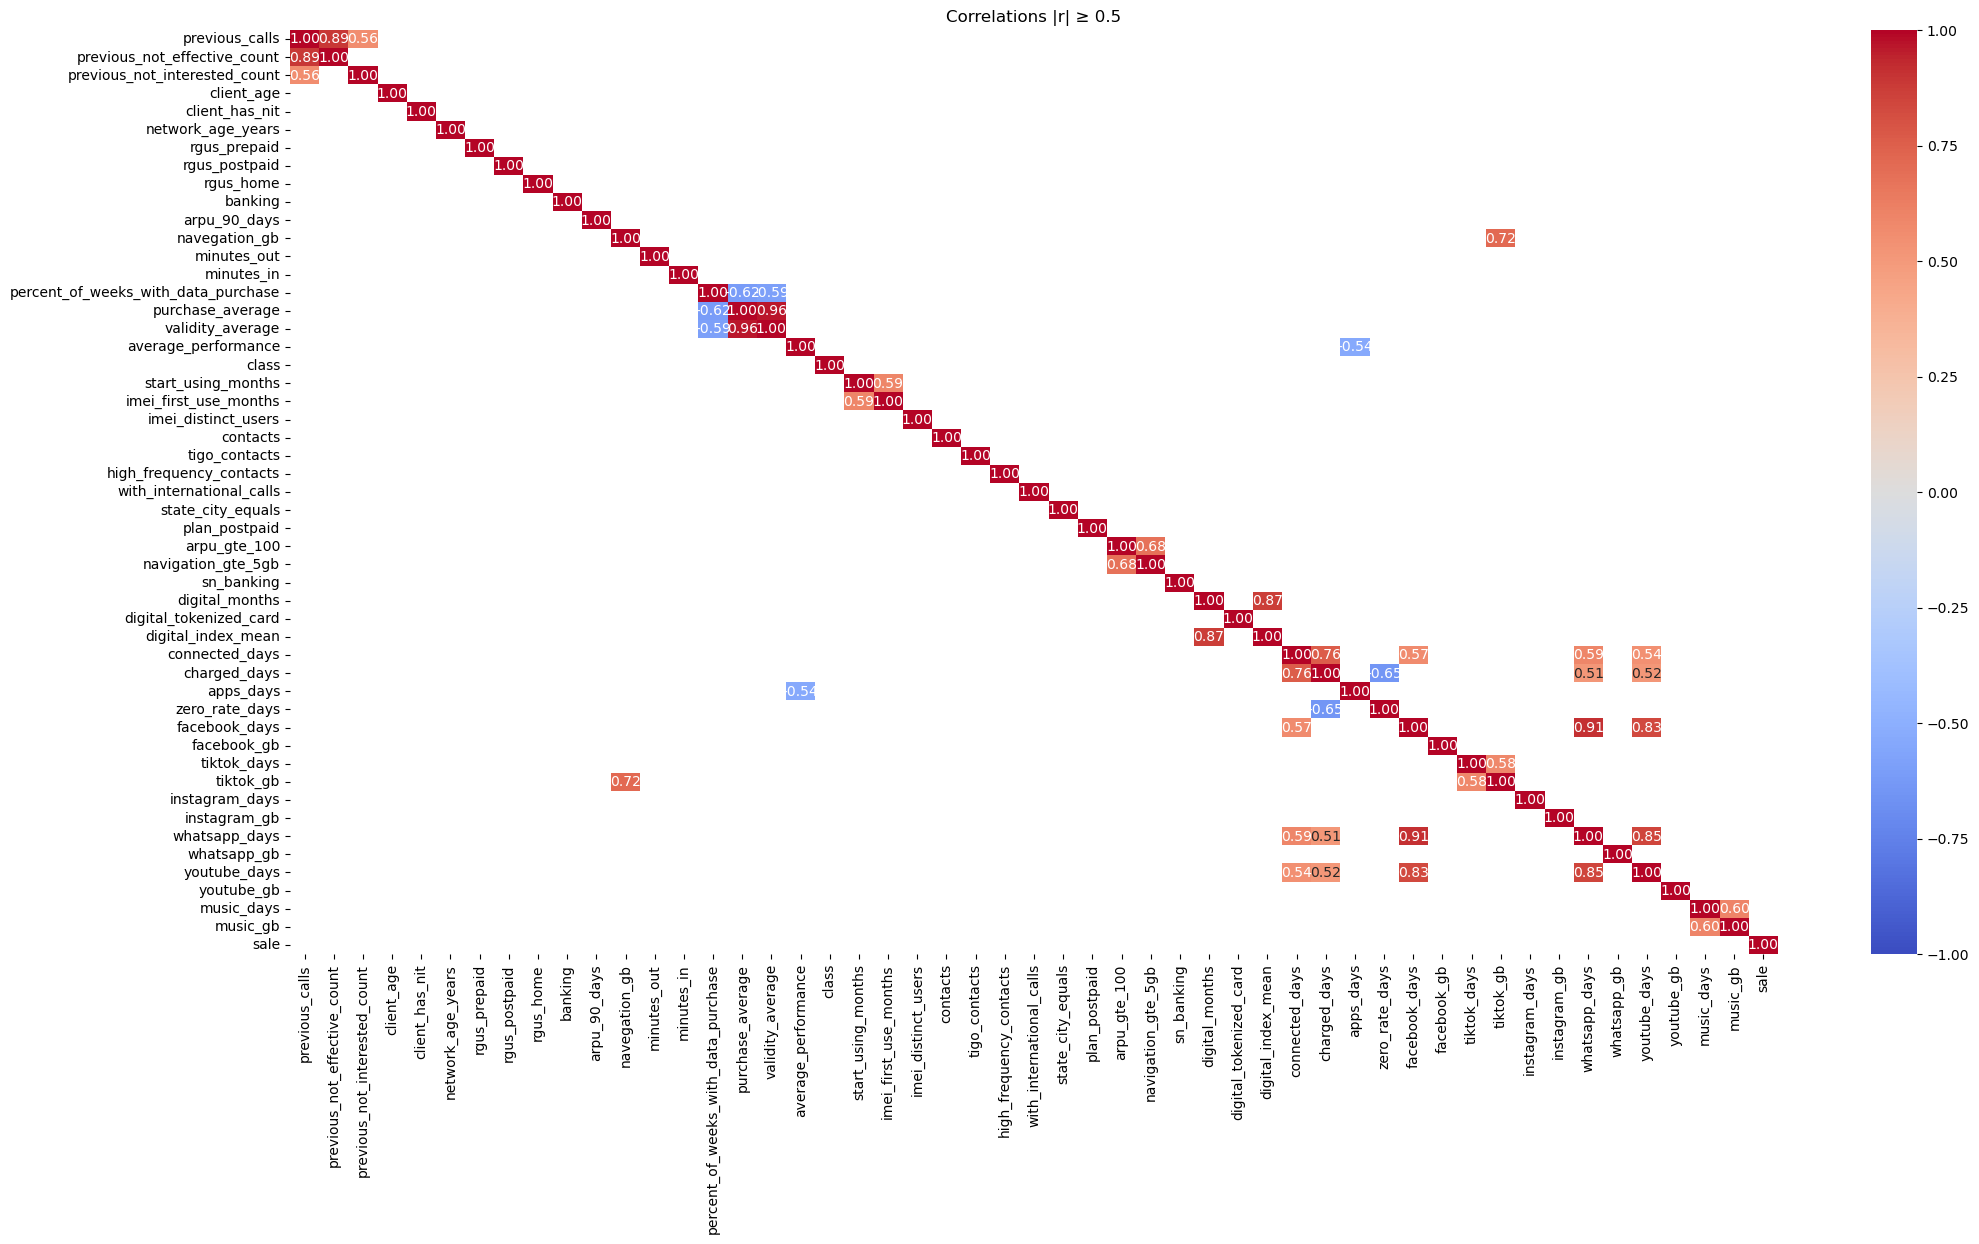

In [157]:
threshold = 0.5
mask = corr.abs() < threshold
filtered_corr = corr.mask(mask)
plot_correlation(filtered_corr, f"Correlations |r| ≥ {threshold}")

#### Correlation with target variable

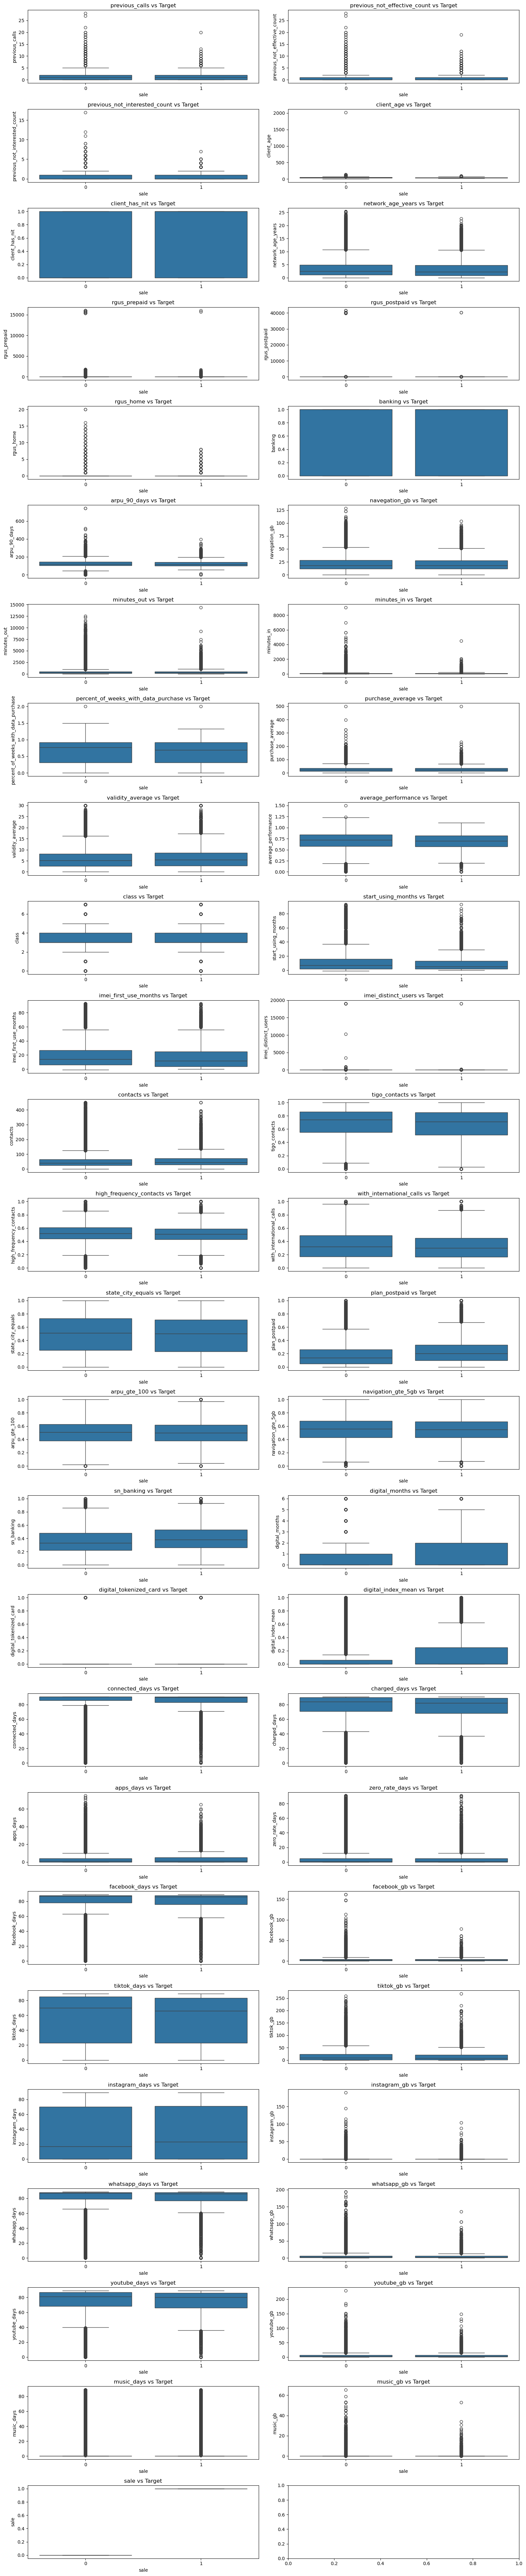

In [162]:
plotBoxplots(df=df, numerical_cols=numerical_variables, target='sale')

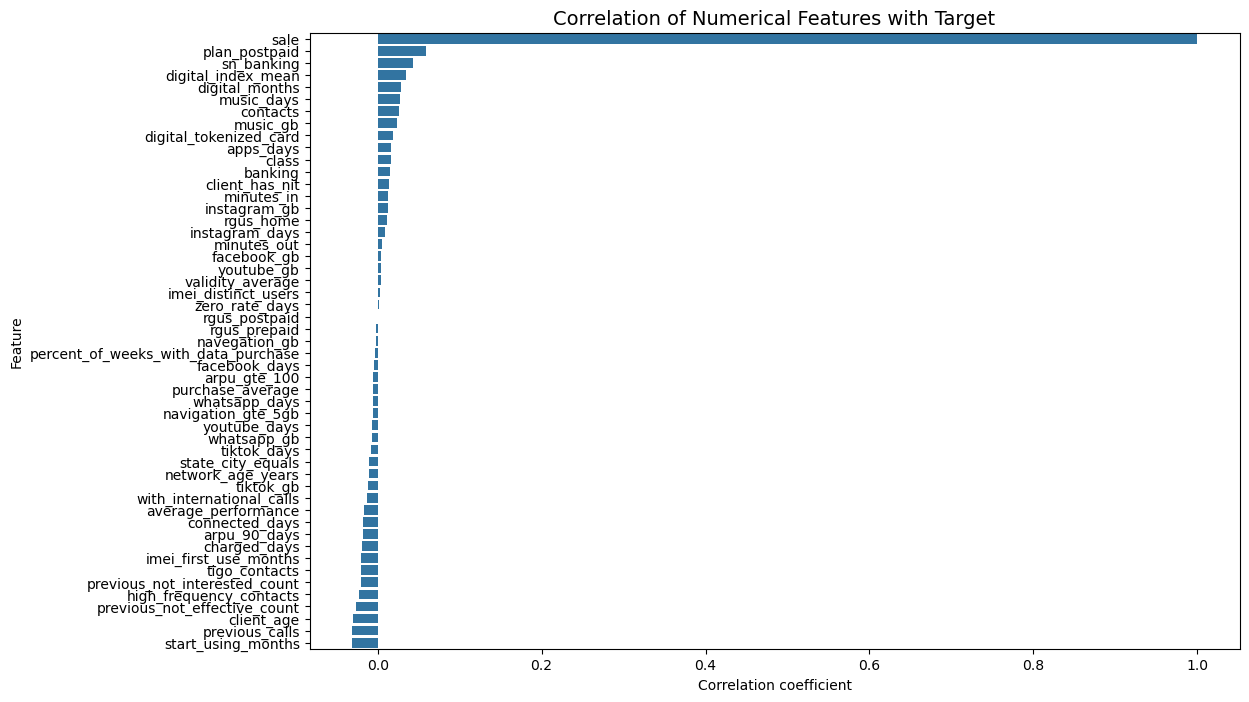

In [165]:
corr = df.corr(numeric_only=True)['sale'].sort_values(ascending=False)
correlation_barplot(corr)

The point-biserial correlation helps us understand how much a numeric feature is related to a yes/no outcome.

It measures the strength and direction of the relationship between:

a binary variable (e.g., sale = 0 or sale = 1), and

a continuous numeric variable (e.g., age, balance, duration, etc.).

If the people who bought (sale = 1) tend to have higher values (like longer calls or larger balances), the correlation will be positive.
If they tend to have lower values, it will be negative.
If it’s close to zero, that means this variable doesn’t really make a difference between buyers and non-buyers.

In [76]:
from scipy.stats import pointbiserialr
import numpy as np

target = 'sale'

# 1) Limpia inf/NaN
df_nan = df.replace([np.inf, -np.inf], np.nan)

# 2) Asegura que NO iteras sobre la target
numerical_variables = [c for c in numerical_variables if c != target]

corrs = {}

for col in numerical_variables:
    # Subconjunto limpio solo con col y target (sin duplicar target)
    clean = df_nan[[col, target]].dropna()

    # Garantiza vectores 1D
    y = clean[target].to_numpy().ravel()
    x = clean[col].to_numpy().ravel()

    # Evita columnas constantes
    if np.unique(x).size < 2:
        continue

    r, p = pointbiserialr(y, x)
    corrs[col] = r

corrs = pd.Series(corrs).sort_values(ascending=False)
print(corrs.head(10))

plan_postpaid             0.058497
sn_banking                0.043175
digital_index_mean        0.033938
digital_months            0.028369
music_days                0.027585
contacts                  0.026299
music_gb                  0.023779
digital_tokenized_card    0.018861
apps_days                 0.015868
class                     0.015703
dtype: float64


### 2.6.3 missing numerical values

In [65]:
missing = df[numerical_variables].isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent.round(2)
})

missing_df

,Missing Values,Percentage
client_age,151524,24.84
imei_distinct_users,19,0.00
imei_first_use_months,19,0.00
start_using_months,19,0.00
class,19,0.00
network_age_years,2,0.00
previous_calls,0,0.00
zero_rate_days,0,0.00
sn_banking,0,0.00
digital_months,0,0.00


### 2.6.4 Outliers

Outlier detection helps identify data points that deviate significantly from other observations.

In this notebook, boxplots are used (see next cell) to visualize outliers for each numerical variable. In a boxplot, outliers are typically shown as points outside the "whiskers" (which represent 1.5 times the interquartile range from the quartiles).

These outliers may indicate errors, rare events, or variability in the data, and can impact model performance.

Detecting and handling outliers is important for robust data analysis and modeling.

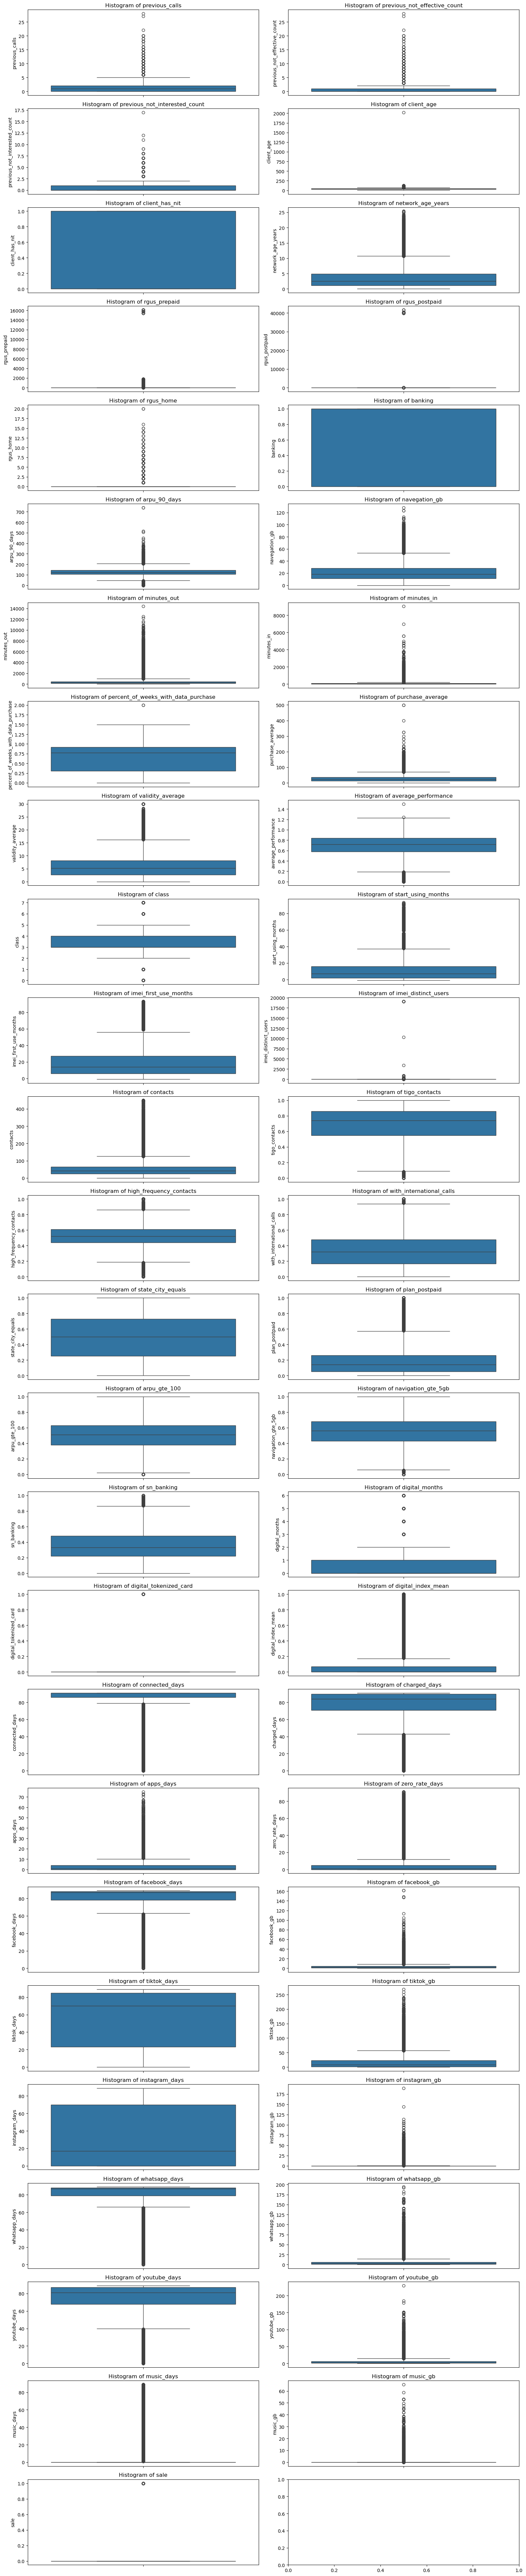

In [166]:
plotBoxplots(df, numerical_cols=numerical_variables, target='')

## 2.8 Categorical Variables

This dataset has 9 categorical variables

In [129]:
categorical_variables = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'categorical variables: {len(categorical_variables)}')

categorical variables: 9


The following tables describes the categorical variables in the dataset making emphasis in:
* Count
* Top
* Frequency

In [130]:
df.describe(include="object").T

,count,unique,top,freq
state_name,610068,22,GUATEMALA,104875
previous_classification,610083,3,NEW CLIENT,231950
client_gender,458428,2,M,247019
socioeconomic_level,610083,6,D,227175
network_technology_code,610064,4,4G,554284
operating_system,610064,9,ANDROID,564097
type_name,610064,4,SMARTPHONE,609528
brand_name,610064,128,SAMSUNG,358068
model_name,610064,2382,SAMSUNG A10S 2GB+32GB,41674


### 2.8.1 Cardinal values
the following instruction will show the cardinal values for categorical variables

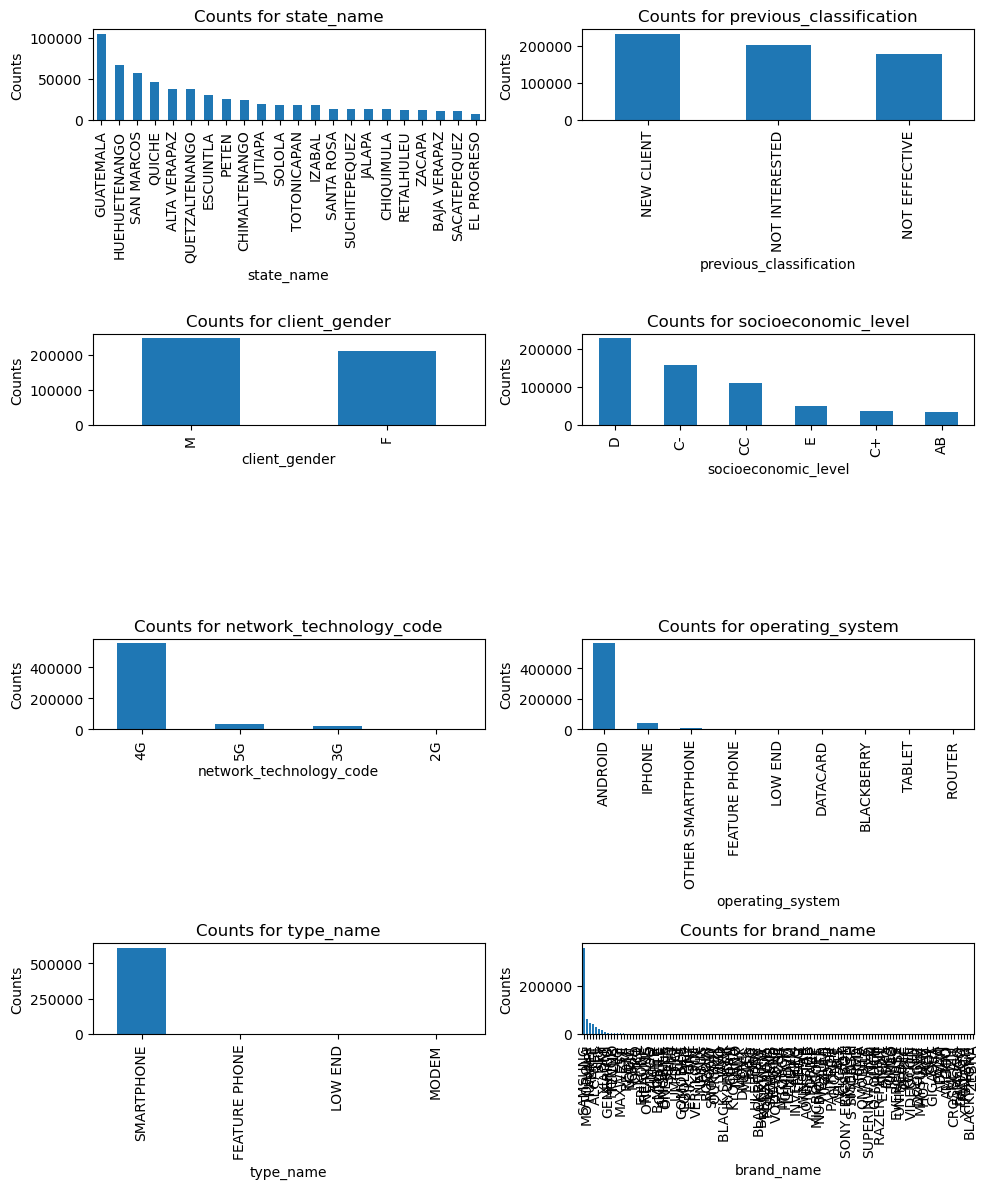

In [132]:
plot_bar(df=df, categorical_vars=categorical_variables)

### 2.8.2 Target distribution by category

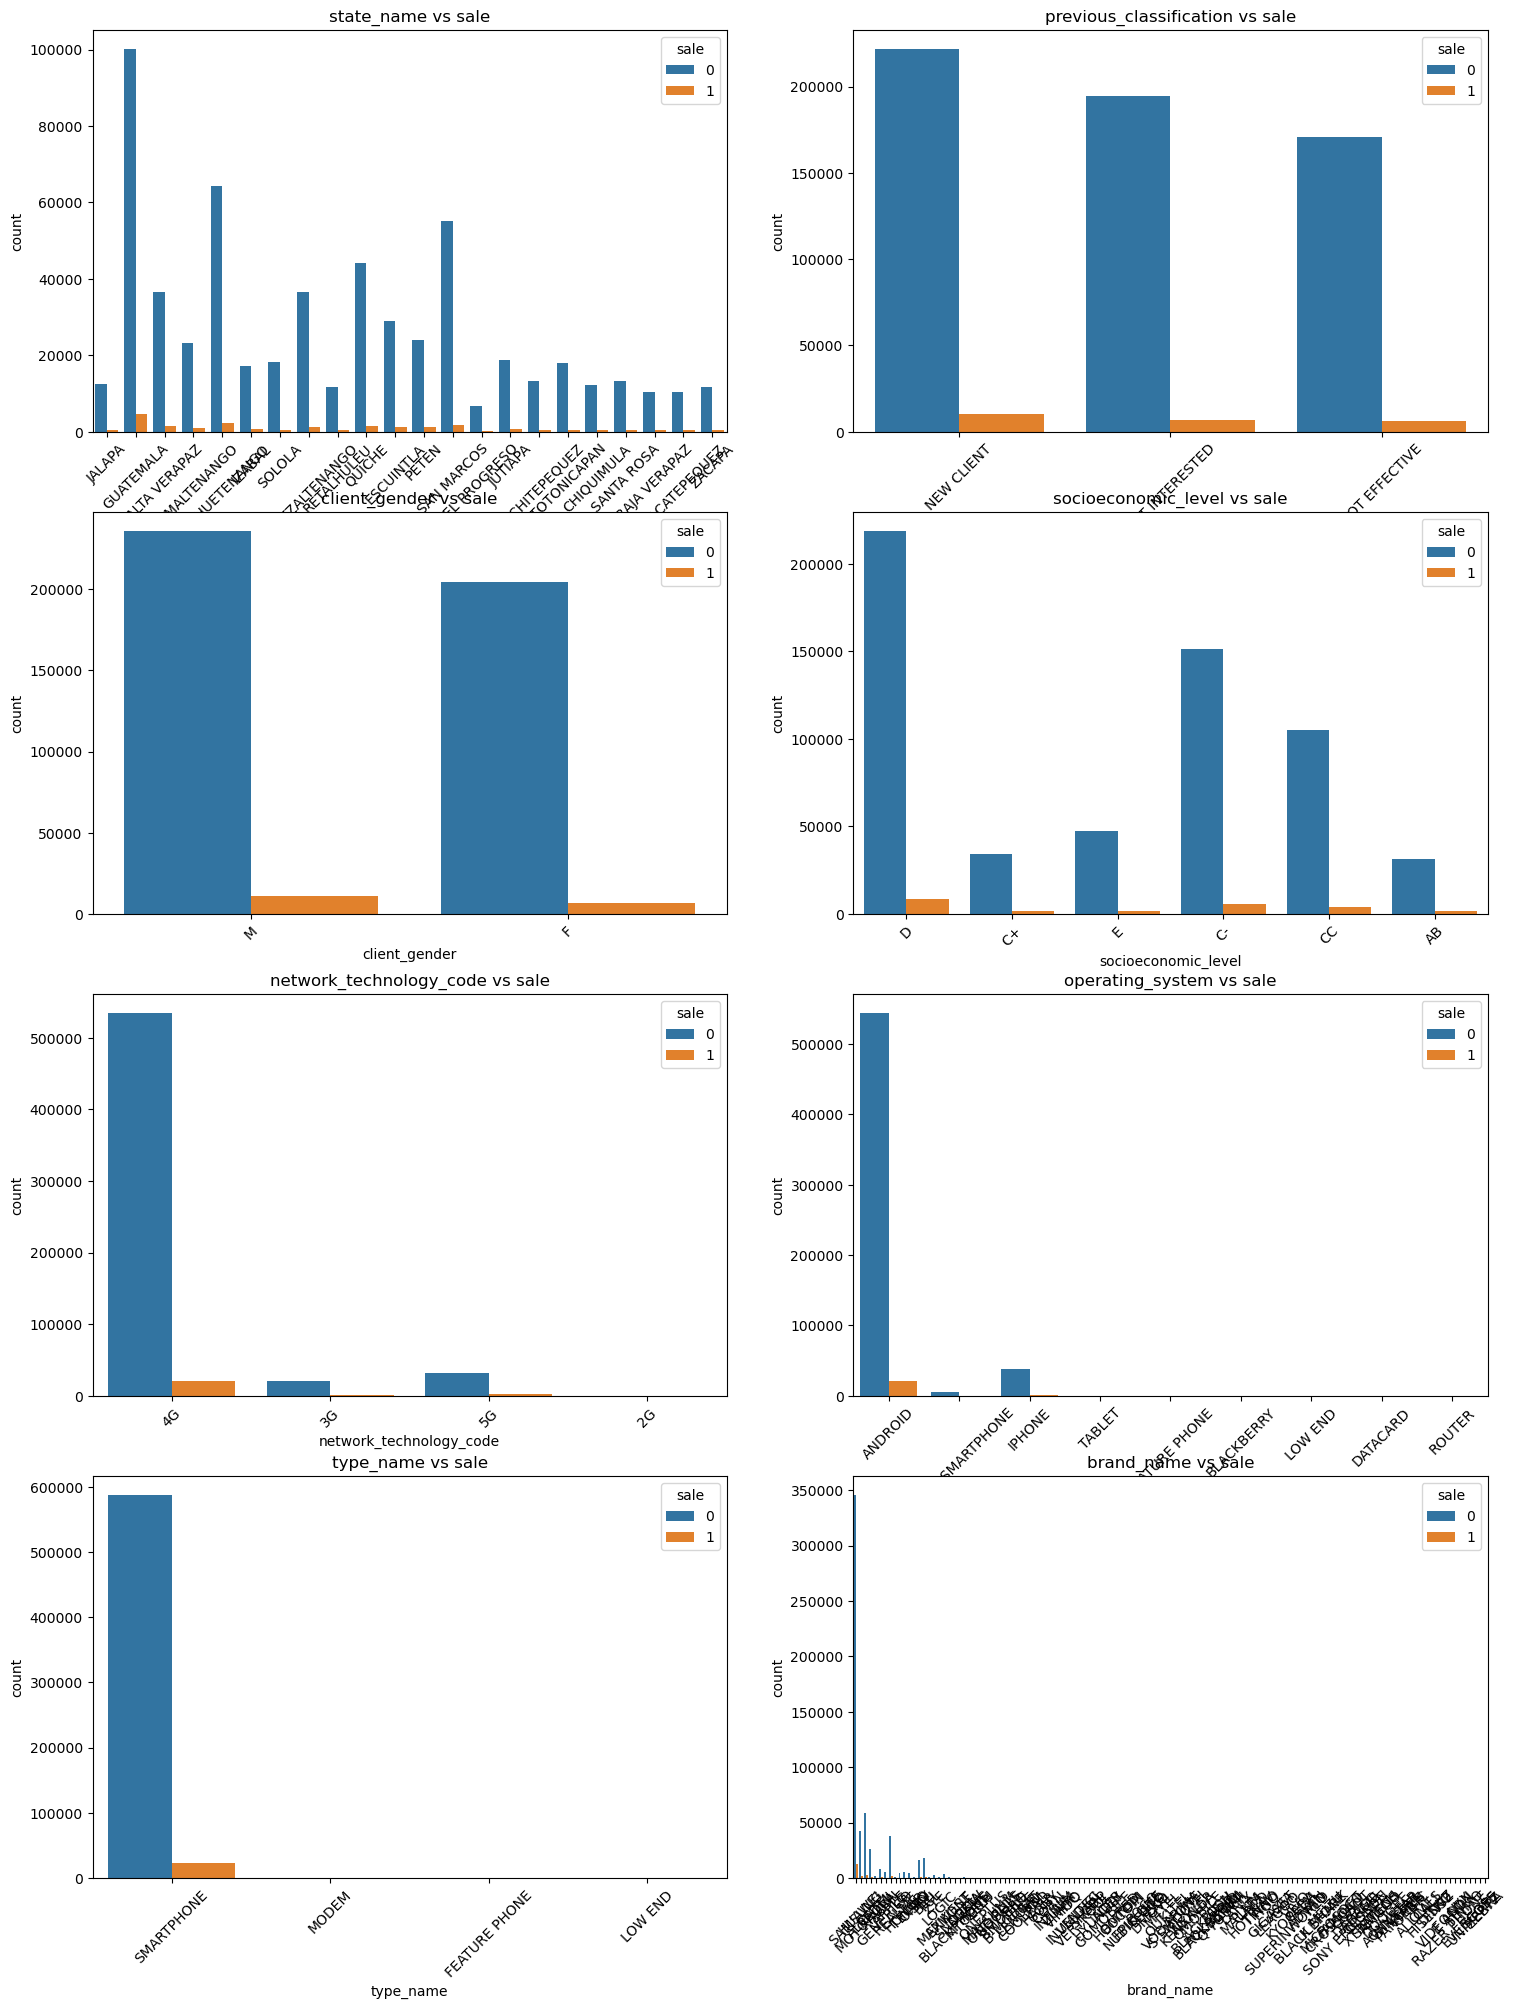

In [148]:
plot_bivariade_bar(df=df, categorical_vars=categorical_variables, target="sale")

### 2.8.3 explaining proportion of sales respectly categorical vars

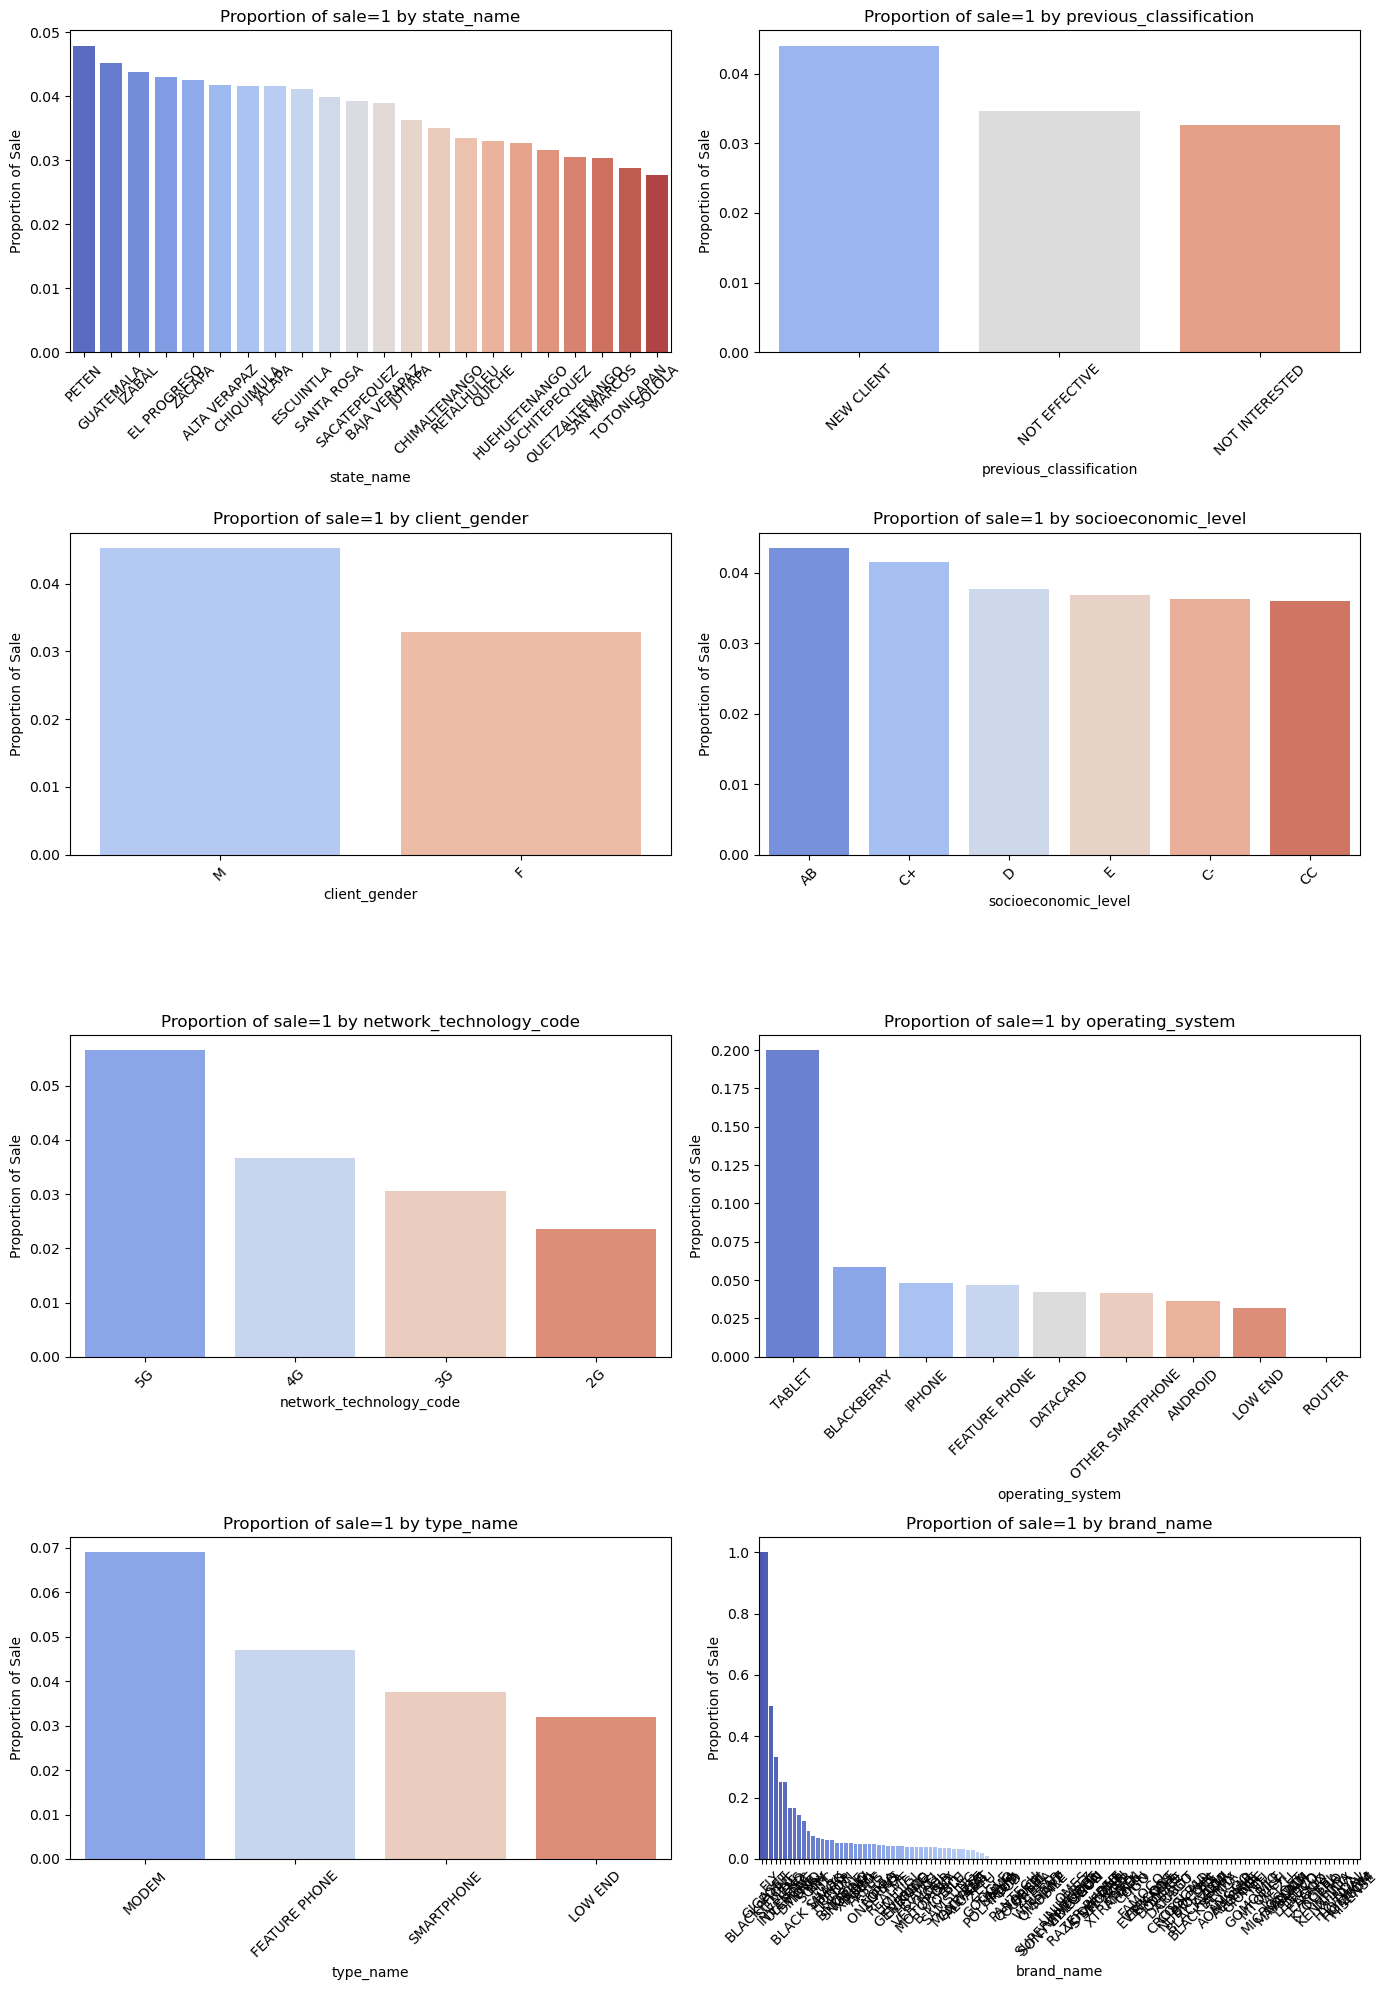

In [141]:
explain_targetWith_cat(df=df, categorical_vars=categorical_variables, target="sale")

### 2.8.4 Missing values

Identifying missing values in a dataset is a crucial step in the data preprocessing phase. Missing values can lead to inaccurate analyses, biased results, and errors in machine learning models. By detecting and handling missing data appropriately, we ensure the integrity and reliability of our subsequent data analysis and modeling processes.

In [149]:
missing = df[categorical_variables].isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent.round(2)
})

missing_df

,Missing Values,Percentage
client_gender,151655,24.86
network_technology_code,19,0.00
operating_system,19,0.00
type_name,19,0.00
brand_name,19,0.00
model_name,19,0.00
state_name,15,0.00
previous_classification,0,0.00
socioeconomic_level,0,0.00


## 2.9 Conclusions

*EDA*

Across all cuts the conversion rate is low (~3–5%), confirming **strong class imbalance**. Categorical signals are material: **previous_classification** is highly informative (NEW CLIENT highest, NOT INTERESTED lowest), **socioeconomic_level** shows a clear gradient (A/B, C+ > C/D/E), and **state_name** differences are present but secondary. **Technology and device** matter: 5G > 4G > 3G > 2G in sale proportion; **SMARTPHONE** dominates volume, while categories like **MODEM/TABLET/BLACKBERRY** can show high lift but with **small sample sizes**; **Android** concentrates most of the base. **brand_name** exhibits a long tail (high cardinality), requiring careful encoding.

Operationally, this suggests prioritizing campaigns toward segments with better **lift × volume** (NEW CLIENT, 4G/5G, higher socioeconomic tiers, smartphones) while tailoring scripts for low-propensity niches (NOT INTERESTED, 2G/3G). For modeling, expect **non-linear, multifactor effects**; use encodings aligned to cardinality (target vs one-hot), **rebalance classes**, and set the operating threshold via **precision/recall/F1** trade-offs. Finally, control for small-n volatility in niche device/OS buckets and keep explainability (e.g., **SHAP**) to translate scores into actionable reasons for telemarketing.
